In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df=pd.read_csv('HousingData.csv')

In [78]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [79]:
df.shape

(506, 14)

In [80]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [81]:
# check for missing values

df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [82]:
df.fillna(df.mean(),inplace=True)

Text(0.5, 1.0, 'Correlation Heatmap')

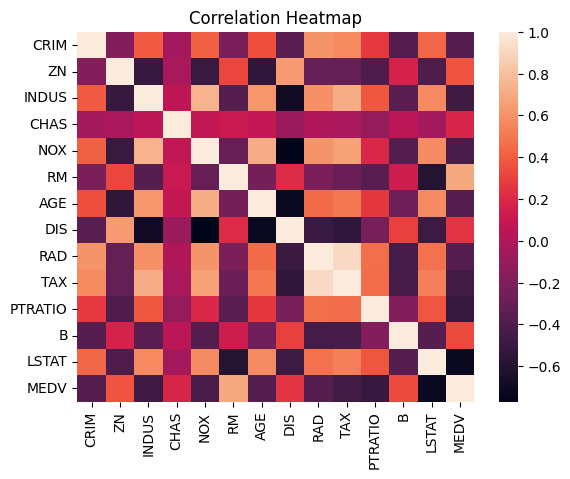

In [83]:
sns.heatmap(df.corr())
plt.title('Correlation Heatmap')

<Axes: xlabel='MEDV', ylabel='Count'>

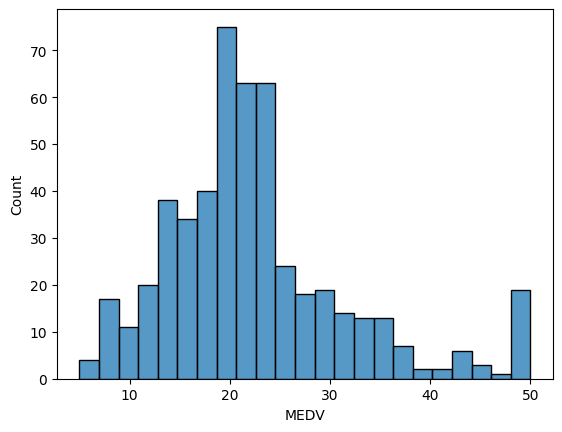

In [84]:
sns.histplot(df['MEDV'])

In [85]:
X=df.drop('MEDV',axis=1)

In [86]:
y=df['MEDV']

In [87]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [88]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [89]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [90]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [91]:
model=Sequential()

model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))

model.add(Dense(1))

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
#compile
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

In [93]:
#train

model.fit(X_train,y_train,validation_split=0.2,epochs=100)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 616.7345 - mae: 23.0050 - val_loss: 545.1661 - val_mae: 21.8176
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 580.8909 - mae: 22.2035 - val_loss: 519.0585 - val_mae: 21.2153
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 539.8511 - mae: 21.3194 - val_loss: 481.0655 - val_mae: 20.3267
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 543.7648 - mae: 21.1257 - val_loss: 422.7578 - val_mae: 18.9043
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 461.4347 - mae: 19.3287 - val_loss: 335.3969 - val_mae: 16.5572
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 333.6234 - mae: 16.0521 - val_loss: 223.7317 - val_mae: 13.1815
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 207.5177 - mae: 12.3352 - val_loss: 111.2086 - val_mae: 8.6489
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 109.0509 - mae: 8.2338 - val_loss: 50.8864 - val_mae: 5.4754
Epoch 9/100
11/

In [94]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,565 (41.27 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,044 (27.52 KB)

In [95]:
#predict
predictions=model.predict(X_test)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000027114D20CC0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


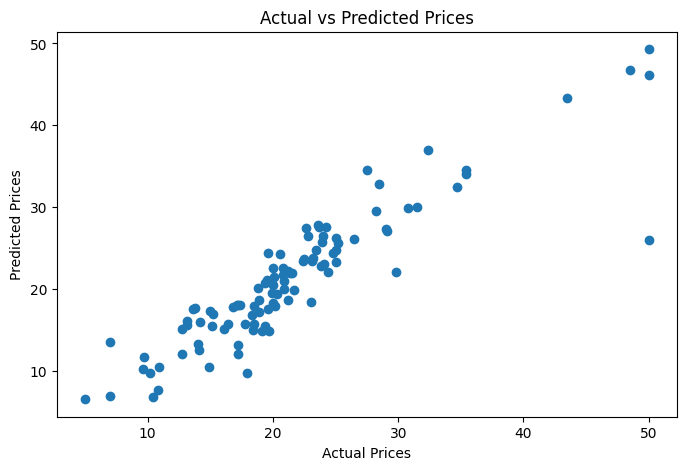

In [96]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')

plt.show()

In [97]:
mae=mean_absolute_error(y_test,predictions)
print("Mean absokute error",mae)

Mean absokute error 2.3359220074672327


In [98]:
mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error:", mse)

Mean Squared Error: 13.080221791855008


In [99]:
rmse=np.sqrt(mse)
print(rmse)

3.6166589266690616


In [100]:
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

R2 Score: 0.8216344332971488


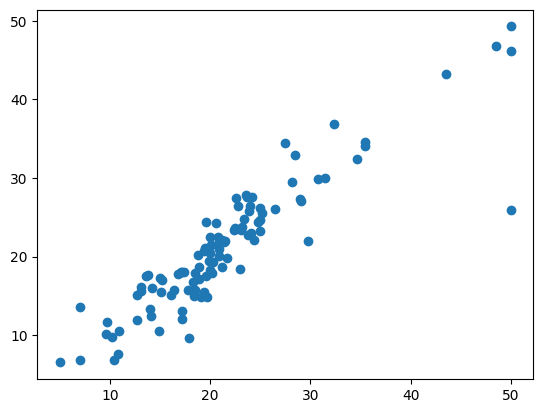

In [101]:
plt.scatter(y_test, predictions)

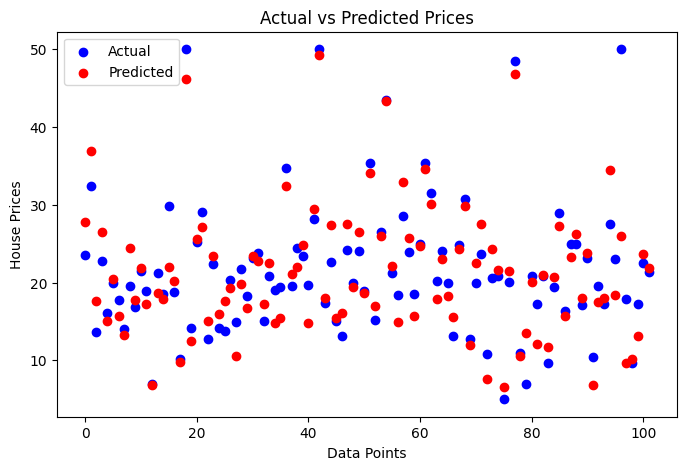

In [103]:
plt.figure(figsize=(8,5))

# Actual values
plt.scatter(
    range(len(y_test)),
    y_test,
    color='blue',
    label='Actual'
)

# Predicted values
plt.scatter(
    range(len(predictions)),
    predictions,
    color='red',
    label='Predicted'
)

plt.xlabel("Data Points")
plt.ylabel("House Prices")
plt.title("Actual vs Predicted Prices")

plt.legend()

plt.show()

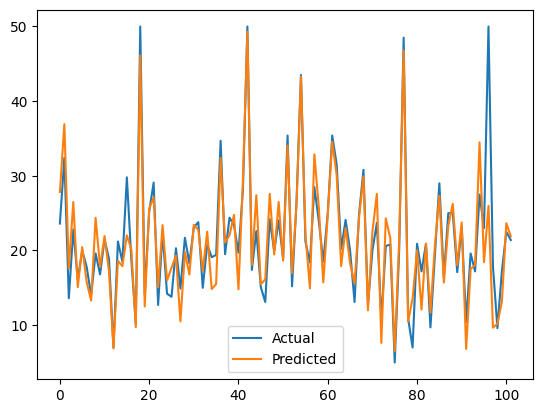

In [104]:
plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.legend()
plt.show()

In [105]:
sample = [[
    0.1, 18.0, 2.31, 0, 0.538,
    6.575, 65.2, 4.09, 1,
    296, 15.3, 396.9, 4.98
]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

print(prediction[0][0])

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
26.443647
